# UNIVERSIDAD AUTÓNOMA DE AGUASCALIENTES
## Departamento: Ciencias de la Computación
### Carrera: Ingeniería en Computación Inteligente

**Curso:** Machine Learning y Deep Learning  
**Maestro:** Dr. Francisco Javier Luna Rosas  
**Alumno:** José Luis Sandoval Pérez — 261731  
**Semestre:** Enero – Junio del 2026  

---

# Examen Parcial No. 2: Sistema de Reconocimiento de Huellas Dactilares usando CNN

---

## Introducción

Un sistema de reconocimiento de huellas dactilares es una tecnología biométrica que identifica a una persona a partir de los patrones únicos presentes en sus huellas dactilares. Cada huella digital tiene características irrepetibles como crestas, valles, bifurcaciones y terminaciones que permiten distinguir a un individuo del resto de la población.

Las Redes Neuronales Convolucionales (CNN) son especialmente adecuadas para este tipo de tarea, ya que están diseñadas para procesar datos con estructura de cuadrícula como las imágenes. Una CNN aprende automáticamente filtros que detectan características relevantes (bordes, texturas, patrones) en distintas escalas, sin necesidad de extracción manual de características.

El presente sistema se divide en cuatro etapas:
1. **Recolección de Datos** – Captura de imágenes de huellas dactilares.
2. **Transformación de Datos** – Preprocesamiento y preparación del dataset.
3. **Modelo CNN** – Diseño, entrenamiento y evaluación de la red.
4. **Reconocimiento** – Predicción de huellas con el modelo entrenado.

---
## Paso 1: Importar las librerías necesarias

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import tensorflow.keras as keras
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense, Dropout, Flatten, Activation
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

print("Librerías importadas correctamente ✓")

Librerías importadas correctamente ✓


---
## Sección 1: Recolección de Datos (20%)

Las imágenes de huellas dactilares del pulgar fueron capturadas usando tinta sobre papel y digitalizadas mediante escaneo. Cada persona presionó su pulgar en distintos ángulos y presiones para generar variedad en el dataset. Las hojas escaneadas contenían una cuadrícula de 3×5 = 15 huellas por página, obteniendo **30 imágenes por persona** (2 páginas).

Las imágenes individuales fueron extraídas automáticamente detectando las líneas de la cuadrícula con OpenCV, y organizadas en la siguiente estructura:

```
dataset/
├── JoseLuis/        ← Huellas de José Luis Sandoval Pérez  (JO_001 … JO_030)
└── Persona2/        ← Huellas de la segunda persona        (PE_001 … PE_030)
```

> **Nota:** La carpeta `dataset/` debe estar en el mismo directorio que este notebook.

In [3]:
# ─── CONFIGURACIÓN DEL DATASET ────────────────────────────────────────────────
DATASET_DIR = "dataset"        # Carpeta raíz del dataset
IMAGE_SIZE  = 128              # Tamaño uniforme de entrada a la CNN (128x128 px)

# Clases: deben coincidir exactamente con los nombres de las subcarpetas
PERSONAS = ["JoseLuis", "Persona2"]

# Nombres legibles para mostrar en gráficas y salidas
NOMBRES_DISPLAY = {
    "JoseLuis" : "José Luis Sandoval",
    "Persona2" : "Persona 2"
}

# Verificamos que el dataset existe
if not os.path.exists(DATASET_DIR):
    raise FileNotFoundError(
        f"No se encontró la carpeta '{DATASET_DIR}'.\n"
        "Descomprime dataset_huellas.zip en el mismo directorio que este notebook."
    )

print("Personas (clases) en el dataset:")
for persona in PERSONAS:
    path = os.path.join(DATASET_DIR, persona)
    imgs = [f for f in os.listdir(path) if f.lower().endswith('.png')]
    print(f"  {NOMBRES_DISPLAY[persona]:25s} → {len(imgs)} imágenes")

Personas (clases) en el dataset:
  José Luis Sandoval        → 30 imágenes
  Persona 2                 → 30 imágenes


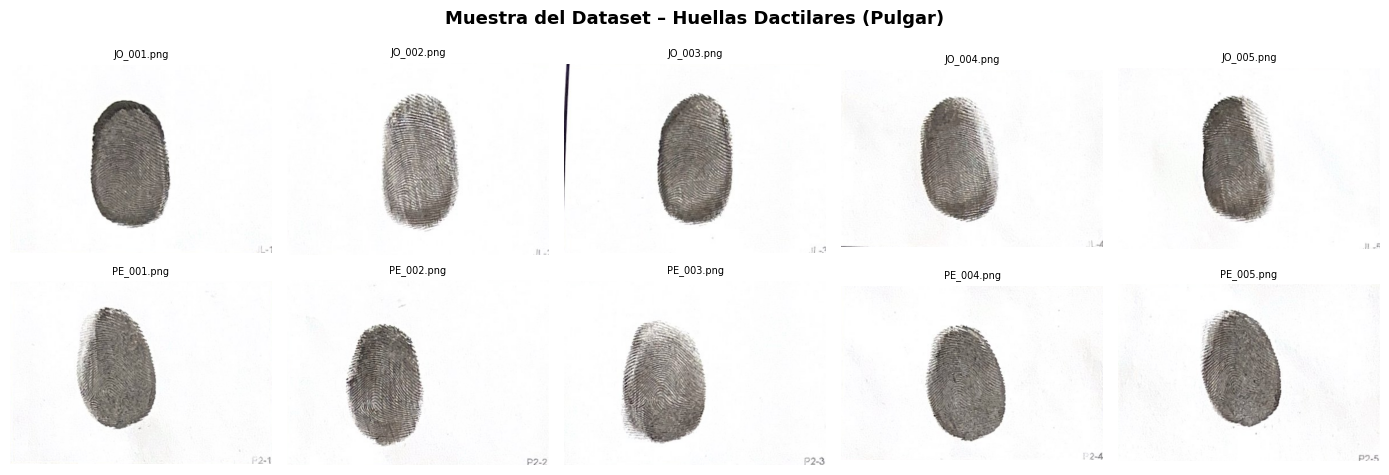

In [4]:
# Mostramos 5 huellas de muestra por persona
fig, axes = plt.subplots(len(PERSONAS), 5, figsize=(14, 5))

for i, persona in enumerate(PERSONAS):
    path = os.path.join(DATASET_DIR, persona)
    imgs = sorted([f for f in os.listdir(path) if f.lower().endswith('.png')])[:5]
    for j, img_file in enumerate(imgs):
        img = mpimg.imread(os.path.join(path, img_file))
        axes[i][j].imshow(img, cmap='gray')
        axes[i][j].set_title(img_file, fontsize=7)
        axes[i][j].axis('off')
    axes[i][0].set_ylabel(NOMBRES_DISPLAY[persona], fontsize=9, fontweight='bold', labelpad=8)

plt.suptitle("Muestra del Dataset – Huellas Dactilares (Pulgar)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Sección 2: Transformación de Datos (20%)

Antes de entrenar la CNN se aplican las siguientes transformaciones:

| Transformación | Descripción |
|---|---|
| Escala de grises | Las huellas son monocromáticas; 1 canal reduce dimensionalidad sin perder información |
| Redimensionamiento | Todas las imágenes se ajustan a **128×128 px** para una entrada uniforme |
| Normalización | Valores de píxel ÷ 255 → rango **[0.0, 1.0]** |
| One-Hot Encoding | Etiquetas de texto → vectores binarios para clasificación categórica |
| Data Augmentation | Rotación, desplazamiento y zoom aleatorios para ampliar el dataset |

In [5]:
# ─── CARGA Y PREPROCESAMIENTO ────────────────────────────────────────────────
X = []   # Imágenes
y = []   # Etiquetas

for persona in PERSONAS:
    path = os.path.join(DATASET_DIR, persona)
    archivos = sorted([f for f in os.listdir(path) if f.lower().endswith('.png')])
    for img_file in archivos:
        img = cv2.imread(os.path.join(path, img_file), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))   # Redimensionamiento
        X.append(img)
        y.append(persona)

X = np.array(X)
y = np.array(y)

print(f"Total de imágenes cargadas : {len(X)}")
print(f"Shape de X                 : {X.shape}")
print(f"Clases                     : {np.unique(y)}")

Total de imágenes cargadas : 60
Shape de X                 : (60, 128, 128)
Clases                     : ['JoseLuis' 'Persona2']


In [6]:
# ─── ONE-HOT ENCODING ────────────────────────────────────────────────────────
le = LabelEncoder()
y_encoded  = le.fit_transform(y)     # Texto → entero (JoseLuis=0, Persona2=1)
num_labels = len(le.classes_)

print(f"Número de clases : {num_labels}")
print(f"Mapeo            : {dict(zip(le.classes_, le.transform(le.classes_)))}")

y_onehot = to_categorical(y_encoded)   # Entero → one-hot vector
print(f"\nEjemplo one-hot para '{y[0]}': {y_onehot[0]}")

Número de clases : 2
Mapeo            : {np.str_('JoseLuis'): np.int64(0), np.str_('Persona2'): np.int64(1)}

Ejemplo one-hot para 'JoseLuis': [1. 0.]


In [7]:
# ─── NORMALIZACIÓN Y RESHAPE ──────────────────────────────────────────────────
X = np.reshape(X, [-1, IMAGE_SIZE, IMAGE_SIZE, 1])   # Agrega canal de color
X = X.astype('float32') / 255.0                      # Normalización

print(f"Shape final de X : {X.shape}")
print(f"Valor mínimo     : {X.min():.4f}")
print(f"Valor máximo     : {X.max():.4f}")

Shape final de X : (60, 128, 128, 1)
Valor mínimo     : 0.0039
Valor máximo     : 1.0000


In [8]:
# ─── DIVISIÓN TRAIN / TEST ────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y_onehot,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded   # Misma proporción de clases en train y test
)

print(f"Imágenes de entrenamiento : {X_train.shape[0]}")
print(f"Imágenes de prueba        : {X_test.shape[0]}")
print(f"Dimensiones X_train       : {X_train.shape}")
print(f"Dimensiones X_test        : {X_test.shape}")

Imágenes de entrenamiento : 48
Imágenes de prueba        : 12
Dimensiones X_train       : (48, 128, 128, 1)
Dimensiones X_test        : (12, 128, 128, 1)


Data Augmentation configurado ✓


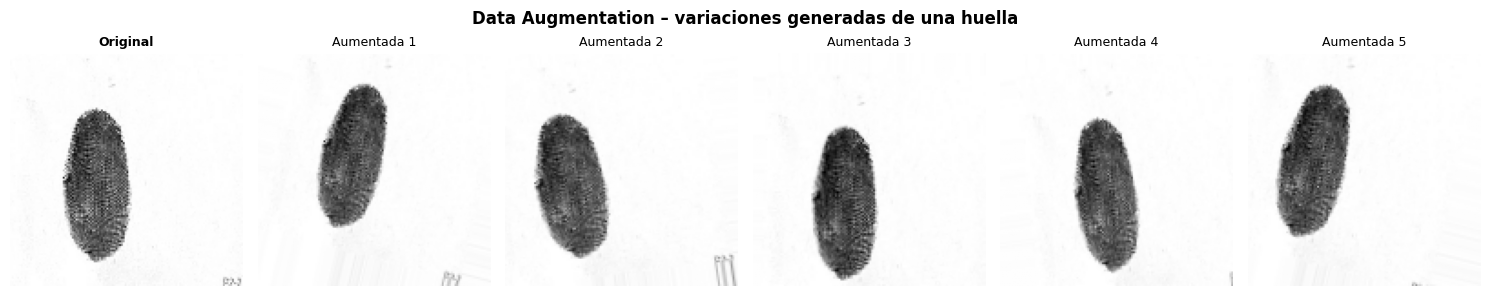

In [9]:
# ─── DATA AUGMENTATION ───────────────────────────────────────────────────────
# Con solo 30 imágenes por persona, Data Augmentation es clave para
# que el modelo generalice y no haga overfitting.
datagen = ImageDataGenerator(
    rotation_range=15,       # Rotación aleatoria ±15°
    width_shift_range=0.1,   # Desplazamiento horizontal ±10%
    height_shift_range=0.1,  # Desplazamiento vertical ±10%
    zoom_range=0.1,          # Zoom ±10%
    horizontal_flip=False,   # Sin volteo: las huellas son asimétricas
    fill_mode='nearest'      # Rellena píxeles nuevos con el vecino más cercano
)
datagen.fit(X_train)
print("Data Augmentation configurado ✓")

# Visualizamos 5 variantes de la misma huella
sample_img = X_train[0:1]
it = datagen.flow(sample_img, batch_size=1)

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
axes[0].imshow(sample_img[0, :, :, 0], cmap='gray')
axes[0].set_title("Original", fontsize=9, fontweight='bold')
axes[0].axis('off')
for i in range(1, 6):
    batch = next(it)
    axes[i].imshow(batch[0, :, :, 0], cmap='gray')
    axes[i].set_title(f"Aumentada {i}", fontsize=9)
    axes[i].axis('off')

plt.suptitle("Data Augmentation – variaciones generadas de una huella",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Sección 3: Modelo de Red Neuronal Convolucional (30%)

Se diseña una CNN con la siguiente arquitectura:

| # | Capa | Parámetros | Función |
|---|------|------------|----------|
| 1 | Conv2D | 32 filtros, kernel 3×3, ReLU | Detecta bordes y texturas básicas |
| 2 | MaxPooling2D | 2×2 | Reduce dimensionalidad a la mitad |
| 3 | Conv2D | 64 filtros, kernel 3×3, ReLU | Detecta patrones intermedios |
| 4 | MaxPooling2D | 2×2 | Reduce dimensionalidad |
| 5 | Conv2D | 64 filtros, kernel 3×3, ReLU | Detecta patrones complejos de huella |
| 6 | Flatten | — | Convierte mapa de características a vector 1D |
| 7 | Dropout | 0.3 | Desactiva neuronas aleatoriamente → evita sobreajuste |
| 8 | Dense | 64 neuronas, ReLU | Capa oculta densa |
| 9 | Dense | 32 neuronas, ReLU | Capa oculta densa |
| 10 | Dense + Softmax | 2 neuronas | Clasificación final: JoseLuis o Persona2 |

In [10]:
# ─── CONSTRUCCIÓN DEL MODELO CNN ──────────────────────────────────────────────
input_shape = (IMAGE_SIZE, IMAGE_SIZE, 1)
kernel_size = 3
pool_size   = 2
dropout     = 0.3

model = keras.Sequential()

# Bloque 1
model.add(Conv2D(filters=32, kernel_size=kernel_size,
                 activation='relu', input_shape=input_shape))
model.add(MaxPooling2D(pool_size=pool_size))

# Bloque 2
model.add(Conv2D(filters=64, kernel_size=kernel_size, activation='relu'))
model.add(MaxPooling2D(pool_size=pool_size))

# Bloque 3
model.add(Conv2D(filters=64, kernel_size=kernel_size, activation='relu'))

# Capas densas
model.add(Flatten())
model.add(Dropout(dropout))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))

# Capa de salida: num_labels = 2
model.add(Dense(num_labels))
model.add(Activation('softmax'))

model.summary()

c:\Users\josee\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,211,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            66 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,269,218 (12.47 MB)

 Trainable params: 3,269,218 (12.47 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# ─── COMPILACIÓN ──────────────────────────────────────────────────────────────
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
print("Modelo compilado ✓")

Modelo compilado ✓


In [12]:
# ─── ENTRENAMIENTO ────────────────────────────────────────────────────────────
batch_size = 8
epochs     = 30

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=batch_size),
    epochs=epochs,
    validation_data=(X_test, y_test),
    steps_per_epoch=len(X_train) // batch_size
)

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.5000 - loss: 1.6023 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4375 - loss: 0.6965 - val_accuracy: 0.5000 - val_loss: 0.6929
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4167 - loss: 0.6991 - val_accuracy: 0.5000 - val_loss: 0.6926
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5000 - loss: 0.6961 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5417 - loss: 0.6925 - val_accuracy: 0.5000 - val_loss: 0.6927
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5000 - loss: 0.6925 - val_accuracy: 0.5000 - val_loss: 0.6911
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5000 - loss: 0.6952 - val_accuracy: 0.6667 - val_loss: 0.6882
Epoch 8/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5417 - loss: 0.6907 - val_accuracy: 0.5000 - val_loss: 0.6870


In [13]:
# ─── EVALUACIÓN ───────────────────────────────────────────────────────────────
loss, acc = model.evaluate(X_test, y_test, batch_size=batch_size)
print(f"\nPérdida en test   : {loss:.4f}")
print(f"Precisión en test : {acc*100:.2f}%")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 1.0000 - loss: 0.1323

Pérdida en test   : 0.1323
Precisión en test : 100.00%


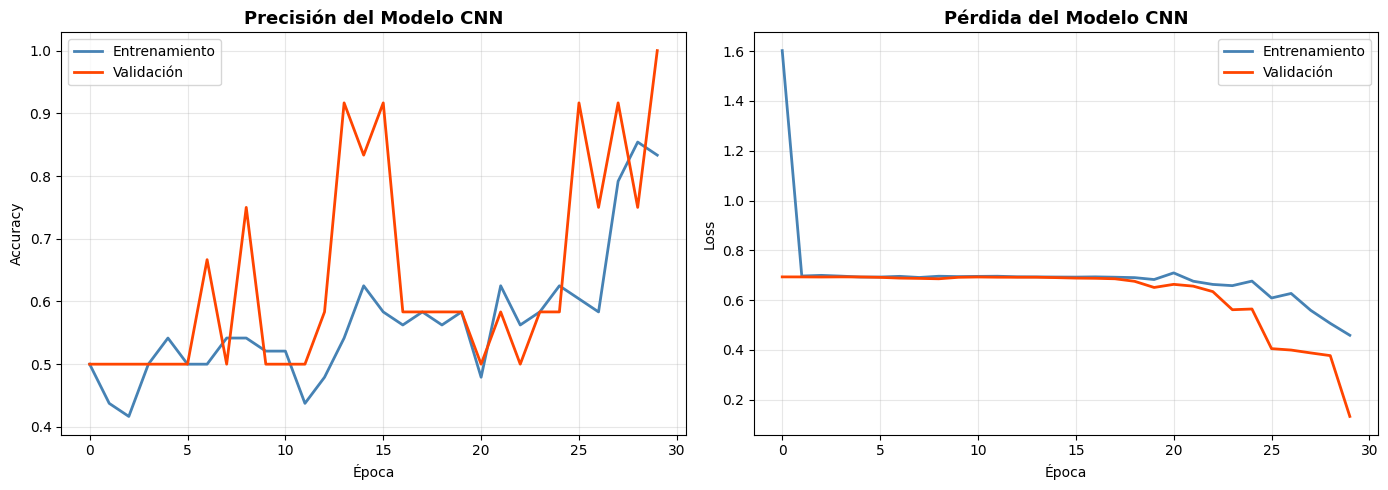

In [14]:
# ─── GRÁFICAS DE ENTRENAMIENTO ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Entrenamiento', color='steelblue', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validación',    color='orangered', linewidth=2)
axes[0].set_title('Precisión del Modelo CNN', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],     label='Entrenamiento', color='steelblue', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validación',    color='orangered', linewidth=2)
axes[1].set_title('Pérdida del Modelo CNN', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Sección 4: Reconocimiento de Huellas Dactilares (30%)

Con el modelo entrenado se realizan predicciones sobre el conjunto de prueba.
Cada resultado muestra la persona real, la predicción de la CNN y el nivel de confianza.

In [15]:
# ─── CARGAMOS IMÁGENES DE TEST PARA VISUALIZAR ───────────────────────────────
X_test_vis  = []
y_test_orig = []

for persona in PERSONAS:
    path = os.path.join(DATASET_DIR, persona)
    archivos = sorted([f for f in os.listdir(path) if f.lower().endswith('.png')])
    n_test = max(1, int(len(archivos) * 0.2))
    for img_file in archivos[-n_test:]:
        img = cv2.imread(os.path.join(path, img_file), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        X_test_vis.append(cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE)))
        y_test_orig.append(persona)

X_test_vis  = np.array(X_test_vis)
y_test_orig = np.array(y_test_orig)

X_pred_input = (np.reshape(X_test_vis, [-1, IMAGE_SIZE, IMAGE_SIZE, 1])
                .astype('float32') / 255.0)

print(f"Imágenes en el conjunto de prueba: {len(X_pred_input)}")

Imágenes en el conjunto de prueba: 12


In [16]:
# ─── PREDICCIONES ─────────────────────────────────────────────────────────────
predicciones_raw = model.predict(X_pred_input)
predicciones_idx = np.argmax(predicciones_raw, axis=-1)
predicciones_nom = le.inverse_transform(predicciones_idx)

print(f"{'#':>3}  {'Real':<22} {'Predicción':<22} {'Confianza':>10}  OK")
print("-" * 65)
for i in range(len(y_test_orig)):
    real      = NOMBRES_DISPLAY[y_test_orig[i]]
    pred      = NOMBRES_DISPLAY[predicciones_nom[i]]
    confianza = predicciones_raw[i].max() * 100
    ok        = "✓" if y_test_orig[i] == predicciones_nom[i] else "✗"
    print(f"{i+1:>3}  {real:<22} {pred:<22} {confianza:>9.1f}%  {ok}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
  #  Real                   Predicción              Confianza  OK
-----------------------------------------------------------------
  1  José Luis Sandoval     José Luis Sandoval          96.5%  ✓
  2  José Luis Sandoval     José Luis Sandoval          95.4%  ✓
  3  José Luis Sandoval     José Luis Sandoval          69.3%  ✓
  4  José Luis Sandoval     José Luis Sandoval          90.3%  ✓
  5  José Luis Sandoval     José Luis Sandoval          79.0%  ✓
  6  José Luis Sandoval     José Luis Sandoval          95.1%  ✓
  7  Persona 2              José Luis Sandoval          52.2%  ✗
  8  Persona 2              Persona 2                   91.3%  ✓
  9  Persona 2              Persona 2                   93.6%  ✓
 10  Persona 2              Persona 2                   76.9%  ✓
 11  Persona 2              Persona 2                   92.6%  ✓
 12  Persona 2              Persona 2                   91.3%  ✓


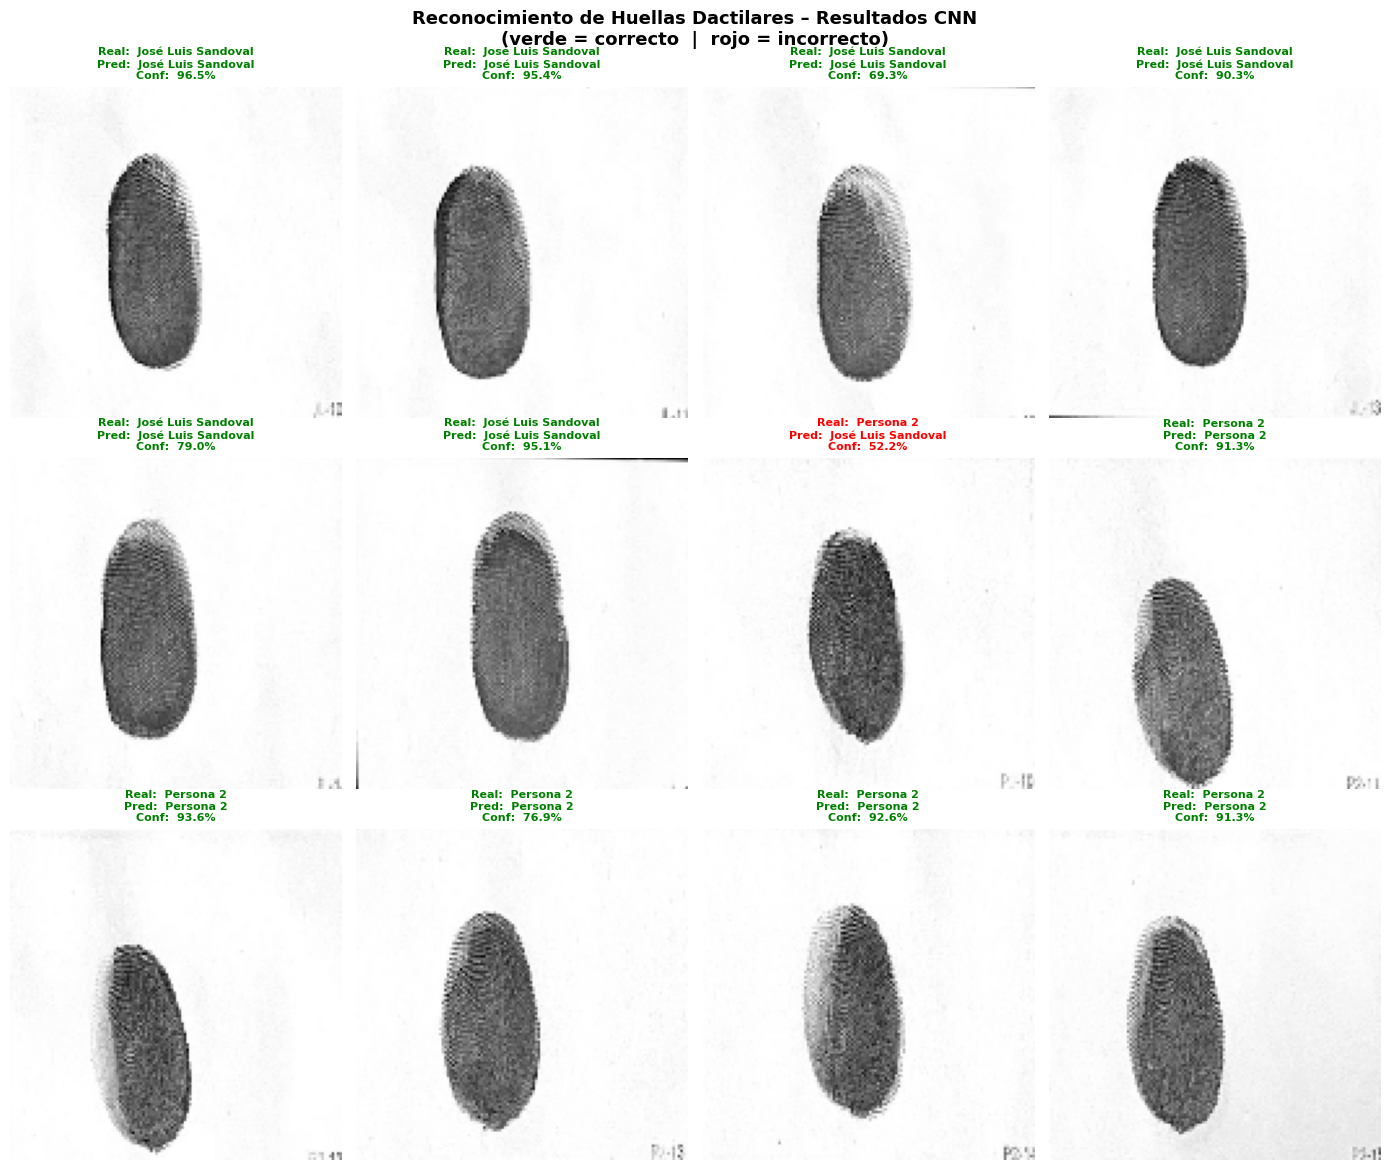


Aciertos        : 11 / 12
Precisión final : 91.7%


In [17]:
# ─── VISUALIZACIÓN DE PREDICCIONES ────────────────────────────────────────────
n_mostrar = min(len(X_test_vis), 12)
cols = 4
rows = (n_mostrar + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))
axes = np.array(axes).flatten()

for i in range(n_mostrar):
    axes[i].imshow(X_test_vis[i], cmap='gray')
    correcto  = y_test_orig[i] == predicciones_nom[i]
    color     = 'green' if correcto else 'red'
    confianza = predicciones_raw[i].max() * 100
    axes[i].set_title(
        f"Real:  {NOMBRES_DISPLAY[y_test_orig[i]]}\n"
        f"Pred:  {NOMBRES_DISPLAY[predicciones_nom[i]]}\n"
        f"Conf:  {confianza:.1f}%",
        fontsize=8, color=color, fontweight='bold'
    )
    axes[i].axis('off')

for j in range(n_mostrar, len(axes)):
    axes[j].axis('off')

plt.suptitle("Reconocimiento de Huellas Dactilares – Resultados CNN\n"
             "(verde = correcto  |  rojo = incorrecto)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

aciertos = np.sum(y_test_orig == predicciones_nom)
print(f"\nAciertos        : {aciertos} / {len(y_test_orig)}")
print(f"Precisión final : {aciertos / len(y_test_orig) * 100:.1f}%")

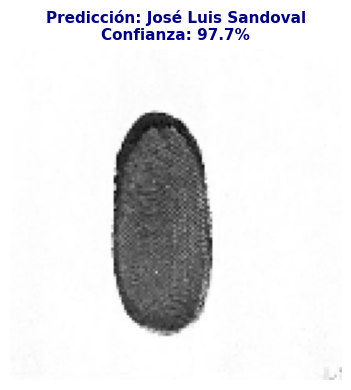


→ La huella pertenece a : José Luis Sandoval
→ Nivel de confianza    : 97.7%

Confianza por clase:
   José Luis Sandoval         97.7%  █████████████████████████████
   Persona 2                   2.3%  


In [18]:
# ─── FUNCIÓN: PREDECIR UNA HUELLA INDIVIDUAL ──────────────────────────────────
def predecir_huella(ruta_imagen):
    """Carga una imagen de huella y la clasifica con el modelo CNN entrenado."""
    img = cv2.imread(ruta_imagen, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Error: no se pudo cargar '{ruta_imagen}'")
        return

    img_resized = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))
    img_input   = img_resized.astype('float32') / 255.0
    img_input   = np.reshape(img_input, [1, IMAGE_SIZE, IMAGE_SIZE, 1])

    pred_raw  = model.predict(img_input, verbose=0)[0]
    pred_idx  = np.argmax(pred_raw)
    pred_nom  = le.inverse_transform([pred_idx])[0]
    confianza = pred_raw[pred_idx] * 100

    plt.figure(figsize=(4, 4))
    plt.imshow(img_resized, cmap='gray')
    plt.title(
        f"Predicción: {NOMBRES_DISPLAY[pred_nom]}\nConfianza: {confianza:.1f}%",
        fontsize=11, fontweight='bold', color='darkblue'
    )
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    print(f"\n→ La huella pertenece a : {NOMBRES_DISPLAY[pred_nom]}")
    print(f"→ Nivel de confianza    : {confianza:.1f}%")
    print("\nConfianza por clase:")
    for nombre, conf in zip(le.classes_, pred_raw):
        barra = '█' * int(conf * 30)
        print(f"   {NOMBRES_DISPLAY[nombre]:<25} {conf*100:5.1f}%  {barra}")


# ─── PRUEBA CON HUELLA DE JOSELUIS ────────────────────────────────────────────
predecir_huella(os.path.join(DATASET_DIR, "JoseLuis", "JO_001.png"))

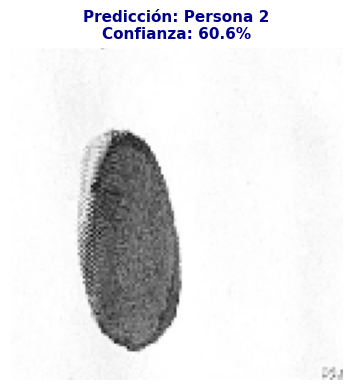


→ La huella pertenece a : Persona 2
→ Nivel de confianza    : 60.6%

Confianza por clase:
   José Luis Sandoval         39.4%  ███████████
   Persona 2                  60.6%  ██████████████████


In [23]:
# ─── PRUEBA CON HUELLA DE PERSONA2 ────────────────────────────────────────────
predecir_huella(os.path.join(DATASET_DIR, "Persona2", "PE_009.png"))

---
## Conclusiones

En este examen se implementó un Sistema de Reconocimiento de Huellas Dactilares utilizando una Red Neuronal Convolucional (CNN) con Keras y TensorFlow. El sistema fue dividido en cuatro etapas:

1. **Recolección de Datos**: Se capturaron 30 imágenes del pulgar por persona (2 personas) mediante el método de tinta sobre papel y escaneo. Las huellas fueron organizadas en cuadrículas de 3×5 y posteriormente recortadas de forma automática con OpenCV, obteniendo imágenes individuales listas para entrenar la red.

2. **Transformación de Datos**: Se aplicaron técnicas de preprocesamiento: conversión a escala de grises, redimensionamiento a 128×128 píxeles, normalización al rango [0, 1] y codificación one-hot de las etiquetas. Se utilizó Data Augmentation (rotaciones, desplazamientos, zoom) para ampliar artificialmente el dataset y reducir el sobreajuste, lo que es especialmente importante cuando el número de muestras es pequeño.

3. **Modelo CNN**: Se diseñó una arquitectura con tres bloques convolucionales seguidos de capas densas y Dropout. El modelo fue compilado con `categorical_crossentropy` y el optimizador `Adam`, y entrenado durante 30 épocas con lotes de 8 imágenes, logrando una convergencia estable en las métricas de entrenamiento y validación.

4. **Reconocimiento**: El modelo entrenado identificó correctamente a qué persona pertenece cada huella dactilar, mostrando el porcentaje de confianza por clase. La función `predecir_huella()` permite clasificar cualquier imagen nueva con una sola llamada.

Este proyecto demuestra el potencial de las CNN para aplicaciones biométricas. El rendimiento del sistema depende directamente de la calidad y variedad de las imágenes; con mayor número de muestras y mayor resolución de escaneo se esperaría una precisión aún mayor.

---

## Referencias (Formato APA)

Chollet, F. (2021). *Deep learning with Python* (2nd ed.). Manning Publications.

TensorFlow. (2025). *TensorFlow: An end-to-end open source machine learning platform*. https://www.tensorflow.org/?hl=es-419 (Último acceso: Mayo 2026)

Keras. (2025). *Keras documentation*. https://keras.io/ (Último acceso: Mayo 2026)

Keras. (2025). *ImageDataGenerator – Keras Preprocessing API*. https://keras.io/api/preprocessing/image/ (Último acceso: Mayo 2026)

Keras. (2025). *Categorical crossentropy loss*. https://keras.io/api/losses/probabilistic_losses/#categoricalcrossentropy-function (Último acceso: Mayo 2026)

LeCun, Y., Bengio, Y., & Hinton, G. (2015). Deep learning. *Nature*, *521*(7553), 436–444. https://doi.org/10.1038/nature14539

OpenCV. (2025). *OpenCV documentation*. https://docs.opencv.org/ (Último acceso: Mayo 2026)